# Customer Churn Prediction

### Project Objective

Analyze customer data to identify factors associated with customer churn, perform data cleaning and feature engineering, and build a machine learning model to predict customer churn.

## Task 5 – Data Loading and SQL Connectivity

In [5]:
import pandas as pd
import pyodbc
print("Pandas version:", pd.__version__)
print("pyodbc imported successfully")

Pandas version: 2.3.3
pyodbc imported successfully


In [6]:
connection_string = (
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=.\\SQLEXPRESS;"
    "Database= ChurnDB;"  
    "Trusted_Connection=yes;"
)
conn = pyodbc.connect(connection_string)
print("Connected to ChurnDB successfully!")

Connected to ChurnDB successfully!


In [7]:
query = "SELECT * FROM [dbo].[vw_ChurnData]"
df = pd.read_sql(query, conn)

C:\Users\nandhini\AppData\Local\Temp\ipykernel_19688\1028094426.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,True,False,1,False,None,DSL,False,...,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.85,False
1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,True,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.50,False
2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,True,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.15,True
3,7795-CFOCW,Male,False,False,False,45,False,None,DSL,True,...,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,False,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.65,True


### Data Inspection

In [26]:
df.shape

(7043, 21)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   bool   
 4   Dependents        7043 non-null   bool   
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   bool   
 7   MultipleLines     6361 non-null   object 
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    5517 non-null   object 
 10  OnlineBackup      5517 non-null   object 
 11  DeviceProtection  5517 non-null   object 
 12  TechSupport       5517 non-null   object 
 13  StreamingTV       5517 non-null   object 
 14  StreamingMovies   5517 non-null   object 
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   bool   
 17  Paymen

In [34]:
# Unique Values
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          2
InternetService        3
OnlineSecurity         2
OnlineBackup           2
DeviceProtection       2
TechSupport            2
StreamingTV            2
StreamingMovies        2
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

### Missing Value Check

In [29]:
df.isnull().sum(axis=0)

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines        682
InternetService        0
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
Churn                  0
dtype: int64

In [40]:
import numpy as np
np.round((df.isnull().sum(axis=0) / len(df)) * 100, 2)

customerID           0.00
gender               0.00
SeniorCitizen        0.00
Partner              0.00
Dependents           0.00
tenure               0.00
PhoneService         0.00
MultipleLines        9.68
InternetService      0.00
OnlineSecurity      21.67
OnlineBackup        21.67
DeviceProtection    21.67
TechSupport         21.67
StreamingTV         21.67
StreamingMovies     21.67
Contract             0.00
PaperlessBilling     0.00
PaymentMethod        0.00
MonthlyCharges       0.00
TotalCharges         0.16
Churn                0.00
dtype: float64

### Observation:

**Eight** columns have missing values. **MultipleLines** has **9.68%** missing values, **six internet-related service columns have 21.67%** missing values each, and **TotalCharges** has only **0.16%** missing values. The missing values in the service columns are related to customers who do not have the corresponding service.

### Missing Value Treatment:

The missing values in the **internet-related service** columns will be treated as **"No internet service"**, because these customers do not have internet service. Similarly, missing values in **MultipleLines** will be as **"No phone service"** for customers who do not have phone service. The few missing **TotalCharges** values will be handled separately after checking their tenure and related billing information.

### Duplicate Records Check

In [35]:
df.duplicated().sum()

np.int64(0)

There are no duplicate records.

### Descriptive Statistics

In [36]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.349998,1397.475000
75%,55.000000,89.849998,3794.737500
max,72.000000,118.750000,8684.800000


In [37]:
df.describe(include='O')

C:\Users\nandhini\AppData\Local\Temp\ipykernel_4856\2537740217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O')


,customerID,gender,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod
count,7043,7043,6361,7043,5517,5517,5517,5517,5517,5517,7043,7043
unique,7043,2,2,3,2,2,2,2,2,2,3,4
top,7590-VHVEG,Male,False,Fiber optic,False,False,False,False,False,False,Month-to-month,Electronic check
freq,1,3555,3390,3096,3498,3088,3095,3473,2810,2785,3875,2365


### Key observations
*  **Tenure:** ranges from **0 to 72 months**. The median is 29 months, meaning half of the customers have been with the company for less than about 29 months.
*  **MonthlyCharges:** ranges from 18.25 to 118.75. The median monthly charge is about 70.35.
*  **TotalCharges:** ranges from 18.80 to 8,684.80. There are 7,032 non-null values out of 7,043, so 11 values are missing. This is something we handled during Task 6.
*  There are **3** different contract types, with **Month-to-month** being the most common.
*  The dataset includes **4 payment methods**, with **Electronic check** being the most commonly used by customers.

## Task 6 – Data Cleaning and Feature Preparation

### Handling Missing Values

In [8]:
df['MultipleLines'] = df['MultipleLines'].fillna("No phone service")

columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',  'TechSupport', 'StreamingTV', 'StreamingMovies']  
for col in columns:
    df[col] = df[col].fillna("No internet service")

In [5]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.549999,NaN
753,0,20.250000,NaN
936,0,80.849998,NaN
1082,0,25.750000,NaN
1340,0,56.049999,NaN
3331,0,19.850000,NaN
3826,0,25.350000,NaN
4380,0,20.000000,NaN
5218,0,19.700001,NaN
6670,0,73.349998,NaN


The **11 missing TotalCharges** values belong to customers with zero tenure. Since these customers have just started their service, the missing total charge is treated as **0** rather than using a statistical value such as the mean or median.

In [9]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [6]:
df.isnull().sum(axis=0)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Feature Preparation

In [10]:
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

In [11]:
bool_col = ['SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'PaperlessBilling', 'Churn']
df[bool_col] = df[bool_col].astype(int)

In [12]:
categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True,  dtype=int)

In [14]:
df.dtypes

customerID                                   str
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_True                         int64
MultipleLines_No phone service             int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_True                        int64
OnlineSecurity_No internet service         int64
OnlineBackup_True                          int64
OnlineBackup_No internet service           int64
DeviceProtection_True                      int64
DeviceProtection_No 

In [13]:
# Remove irrelevant customer ID column
df = df.drop(columns=['customerID'])

In [14]:
# Save the cleaned dataset as a CSV file
df.to_csv('cleaned_churn_data.csv', index=False)

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_No internet service,StreamingTV_True,StreamingTV_No internet service,StreamingMovies_True,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.850000,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.950001,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.849998,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.299999,1840.75,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.699997,151.65,1,...,0,0,0,0,0,0,0,0,1,0


## Task 8 – Feature Engineering

In [23]:
df['tenure'].min(), df['tenure'].max()

(np.int64(0), np.int64(72))

In [15]:
service_columns = [
    'OnlineSecurity_True',
    'OnlineBackup_True',
    'DeviceProtection_True',
    'TechSupport_True',
    'StreamingTV_True',
    'StreamingMovies_True'
]
df['TotalServiceUsed'] = df[service_columns].sum(axis=1)

In [14]:
df['TotalServiceUsed'].value_counts().sort_index()

TotalServiceUsed
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

In [33]:
df[['TotalServiceUsed', 'Churn']].corr()

,TotalServiceUsed,Churn
TotalServiceUsed,1.000000,-0.087698
Churn,-0.087698,1.000000


**TotalServicesUsed** has a **weak negative** correlation with churn **(-0.0877)**. This means customers who use more services are slightly less likely to churn, but it does not strongly say that they will not churn.

In [16]:
df['AvgMonthlySpend'] = 0.0

mask = df['tenure'] > 0

df.loc[mask, 'AvgMonthlySpend'] = (
    df.loc[mask, 'TotalCharges'] / df.loc[mask, 'tenure']
)

In [21]:
df[['tenure', 'TotalCharges', 'AvgMonthlySpend']].head(10)

,tenure,TotalCharges,AvgMonthlySpend
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000
5,8,820.50,102.562500
6,22,1949.40,88.609091
7,10,301.90,30.190000
8,28,3046.05,108.787500
9,62,3487.95,56.257258


In [41]:
df[['AvgMonthlySpend', 'Churn']].corr()

,AvgMonthlySpend,Churn
AvgMonthlySpend,1.000000,0.193301
Churn,0.193301,1.000000


**AvgMonthlySpend** has a **weak positive correlation** with churn **(0.1933)**. This meansCustomers with higher average monthly spending are slightly more likely to churn, , but the relationship is not strong.

In [17]:
def customer_segment(x):
    if x <= 12:
        return "New"
    elif x <= 36:
        return "Established"
    else:
        return "Loyal"

In [18]:
df['CustomerSegment'] = df['tenure'].apply(customer_segment)

In [44]:
df['CustomerSegment'].value_counts()

CustomerSegment
Loyal          3001
New            2186
Established    1856
Name: count, dtype: int64

In [45]:
df.groupby('CustomerSegment')['Churn'].mean()

CustomerSegment
Established    0.255388
Loyal          0.119294
New            0.474382
Name: Churn, dtype: float64

CustomerSegment is a useful feature because **New customers** have a **higher churn rate**, while **Loyal customers** have a **lower churn rate**. This shows that customer tenure is related to churn.

In [24]:
df[['TotalServiceUsed', 'AvgMonthlySpend', 'CustomerSegment']].head()

,TotalServiceUsed,AvgMonthlySpend,CustomerSegment
0,1,29.850000,New
1,2,55.573529,Established
2,2,54.075000,New
3,3,40.905556,Loyal
4,0,75.825000,New


In [50]:
df.shape

(7043, 34)

In [19]:
segment_mapping = {
    'New': 0,
    'Established': 1,
    'Loyal': 2
}

df['CustomerSegment'] = df['CustomerSegment'].map(segment_mapping)

## Task 9 – Baseline Model: Logistic Regression

In [20]:
# Define input features (X) and target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

### Train/test split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 33), (1409, 33), (5634,), (1409,))

In [22]:
# Train the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

C:\Users\nandhini\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
# predictions on 5 test customers
y_pred[:5]

array([0, 1, 0, 0, 0])

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8062455642299503


Logistic Regression achieved an accuracy of **80.62%** on the test data. The model correctly predicted the churn status of approximately **81% of customers**.

## Model Evaluation

Baseline Logistic Regression - Churn Class Results
Precision: 0.6603174603174603
Recall   : 0.5561497326203209
F1-score : 0.6037735849056604

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:
[[928 107]
 [166 208]]


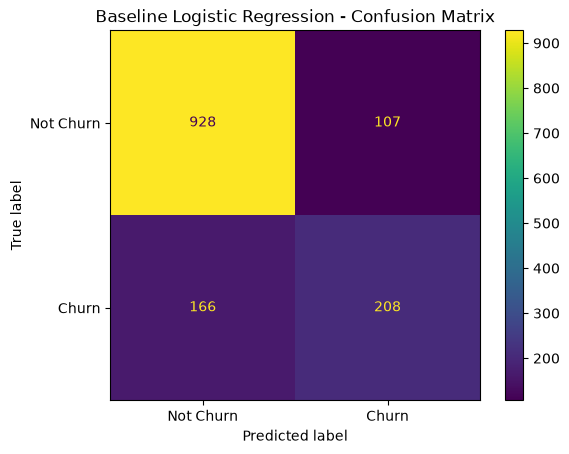

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Churn class = 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("Baseline Logistic Regression - Churn Class Results")
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Churn", "Churn"]
)

plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

*  The model is good at identifying customers who do not churn, with a recall of 90%. For customers who **churn**, the model has a **precision of 66%** and a **recall of 56%**. This means the model **correctly identifies 56%** of the customers who actually **churns**, but misses about **44%** of them. From a business perspective, recall is important because identifying more customers who may churn can help the company take action to retain them.
*  The confusion matrix shows that the model **correctly** identified **208** customers who **churned**. However, it **missed 166 customers** who actually churned and predicted them as **non-churn**. This shows that the model still needs improvement in identifying customers who are likely to churn.

### Checking Class Imbalance

In [42]:
y_train.value_counts(normalize= True)*100

Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

The dataset has a **class imbalance**. About **73.46%** of the customers are **non-churn** customers, while only **26.54%** are **churn** customers. Since there are more non-churn customers, the model may **predict** more customers as **non-churn**. This caused the model to **miss 165 customers** who actually churned, which resulted in a lower recall of 56% for the churn class. we will use **SMOTE** to balance the training data and improve the model's ability to identify churn customers.


In [44]:
import imblearn
print(imblearn.__version__)

0.14.2


In [45]:
print("Class distribution before SMOTE:")
print(y_train.value_counts())

Class distribution before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


### Applying SMOTE to Training Data

In [24]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

Class distribution after SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


### Retrain Logistic Regression with SMOTE

In [36]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression on SMOTE-balanced data
smote_model = LogisticRegression(max_iter=1000, random_state=42)

smote_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression model trained successfully on SMOTE-balanced data.")

Logistic Regression model trained successfully on SMOTE-balanced data.


C:\Users\nandhini\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### SMOTE Model Evaluation

Classification Report - SMOTE Model:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.56      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409


Confusion Matrix - SMOTE Model:
[[840 195]
 [125 249]]


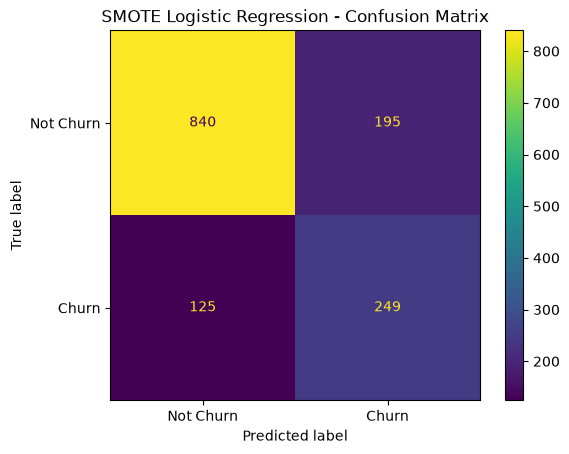

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions on the unchanged test data
y_pred_smote = smote_model.predict(X_test)

# Classification Report
print("Classification Report - SMOTE Model:")
print(classification_report(y_test, y_pred_smote))

# Confusion Matrix
print("\nConfusion Matrix - SMOTE Model:")
cm_smote = confusion_matrix(y_test, y_pred_smote)
print(cm_smote)

# Confusion Matrix Visualization
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote,
    display_labels=["Not Churn", "Churn"]
)

plt.title("SMOTE Logistic Regression - Confusion Matrix")
plt.show()

* After applying SMOTE, the **recall** for churn **increased from 56% to 67%**. This means the model can now identify more customers who actually churn.
* The model correctly identified **249 churned** customers but **missed 125 churned customers** and predicted them as non-churn. Although the overall accuracy decreased slightly, the improvement in churn recall is more important for this task.

### Logistic Regression – Hyperparameter Tuning

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Create Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Define hyperparameters to tune
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Train on SMOTE-balanced training data
grid_lr.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_lr.best_params_)
print("Best Cross-Validation Recall:", grid_lr.best_score_)

Best Parameters: {'C': 0.01}
Best Cross-Validation Recall: 0.8207472442738728


C:\Users\nandhini\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Tuned Logistic Regression – Test Evaluation

Classification Report - Tuned Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409


Confusion Matrix:
[[808 227]
 [110 264]]


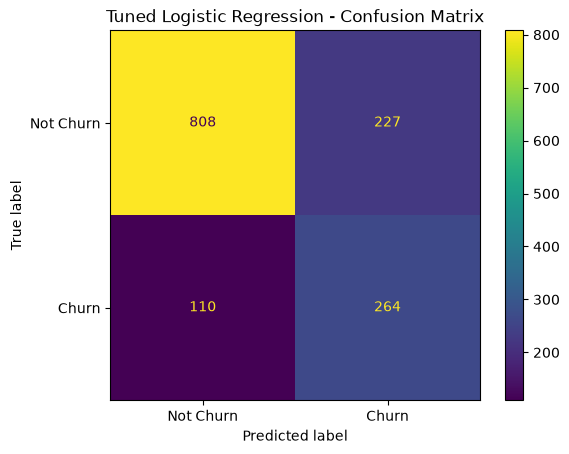

In [39]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Best Logistic Regression model from GridSearchCV
best_lr = grid_lr.best_estimator_

# Predict on the test data
y_pred_lr = best_lr.predict(X_test)

# Classification Report
print("Classification Report - Tuned Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

# Visualize Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Not Churn", "Churn"]
)

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.show()

* The **recall** for the churn class improved from **67 to 71%** after tuning the model. However, the model still misses **29% of customers** who actually churn. This shows that tuning improved the model's ability to identify churn customers, but there is still room for improvement.
* The model correctly identified **264** customers who actually **churned**. However, it failed to identify **110** customers who actually churned and predicted them as non-churn.

### Random Forest – Hyperparameter Tuning

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Create Random Forest model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameters to tune
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Train on SMOTE-balanced training data
grid_rf.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_rf.best_params_)
print("Best Cross-Validation Recall:", grid_rf.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Recall: 0.8724427387273715


### Tuned Random Forest – Test Evaluation

Classification Report - Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409


Confusion Matrix:
[[766 269]
 [ 86 288]]


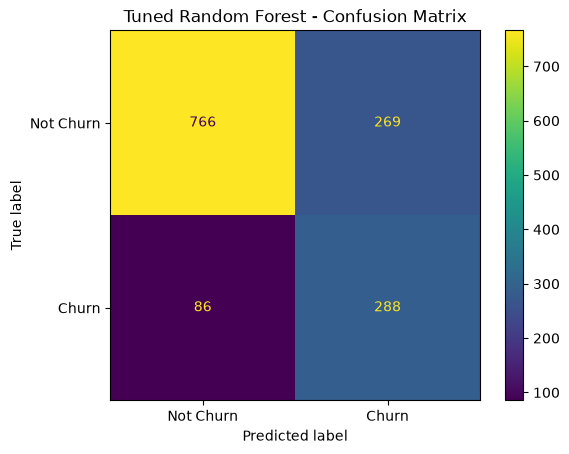

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get the best Random Forest model
best_rf = grid_rf.best_estimator_

# Predict on the unchanged test data
y_pred_rf = best_rf.predict(X_test)

# Classification Report
print("Classification Report - Tuned Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Visualize Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Not Churn", "Churn"]
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

* The Random Forest model achieved a higher **recall** of **77%** for the churn class compared to 71% for the tuned Logistic Regression model. This means it correctly identifies more customers who actually churn. However, it still **misses** about **23%** of the customers who actually churn, so there is still room for improvement.
* The model correctly identified **288** customers who **actually left**. However, it failed to identify **86** customers who actually left and predicted them as customers who would stay.

### Feature Importance — Random Forest Model

In [28]:
# Feature Importance - Tuned Random Forest

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
26,Contract_Two year,0.144465
4,tenure,0.100450
13,OnlineSecurity_True,0.093085
19,TechSupport_True,0.078830
25,Contract_One year,0.064247
32,CustomerSegment,0.062048
11,InternetService_Fiber optic,0.043605
3,Dependents,0.039268
8,TotalCharges,0.036232
18,DeviceProtection_No internet service,0.035683


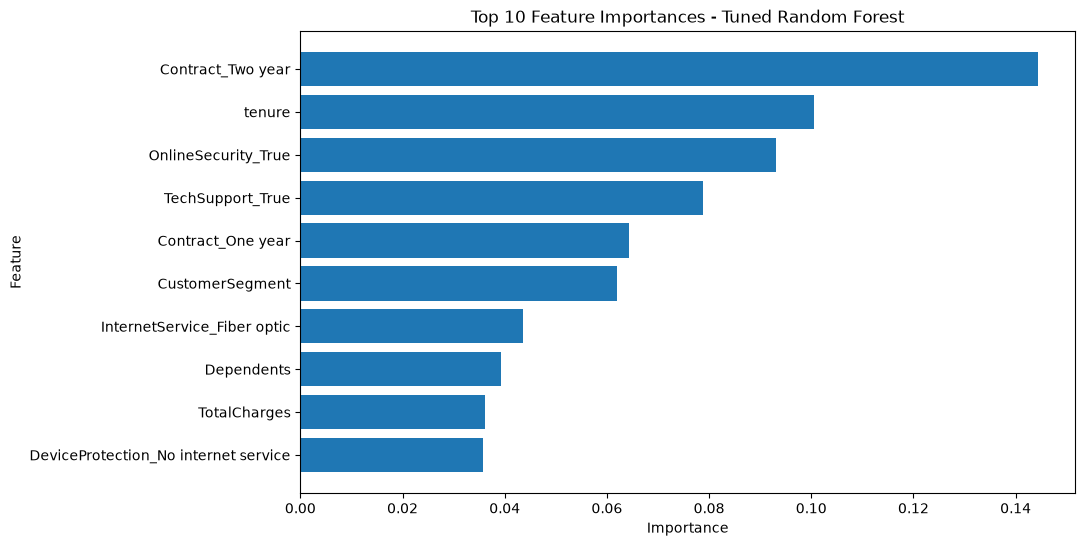

In [29]:
# Visualize Top 10 Feature Importances

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'].head(10)[::-1],
    feature_importance['Importance'].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Tuned Random Forest")
plt.show()

* The Random Forest model identified **contract type, tenure, online security, and technical support** as some of the **most influential features** in predicting customer churn.
* And there is an interesting observation here is **Contract — Two ** has the highest importance, followed by **tenure.** This aligns with the EDA findings that customers with longer-term contracts and longer tenure tend to be more likely to remain with the company.

### XGBoost – Hyperparameter Tuning

In [58]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 5.7 MB/s eta 0:00:09
   - -------------------------------------- 1.6/48.9 MB 5.1 MB/s eta 0:00:10
   -- ------------------------------------- 2.6/48.9 MB 4.6 MB/s eta 0:00:11
   -- ------------------------------------- 3.7/48.9 MB 4.6 MB/s eta 0:00:10
   --- ------------------------------------ 4.5/48.9 MB 4.6 MB/s eta 0:00:10
   ---- ----------------------------------- 5.5/48.9 MB 4.7 MB/s eta 0:00:10
   ----- ---------------------------------- 6.6/48.9 MB 4.6 MB/s eta 0:00:10
   ------ --------------------------------- 7.6/48.9 MB 4.6 MB/s eta 0:00:09
   ------ --------------------------------- 8.4/48.9 MB 4.6 MB/s eta 0:00:09
   ------- -------------------------------- 9.4/48.9 MB 4.6 MB/s eta 0:00:09
   -------- ------------------------------- 10.5/48.9 MB 4.6 MB/s eta 0:00:09
   --------- ------------------------------ 11.5/48.9 MB 4.6 MB/s eta 0:00:09
   -

In [61]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Create XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Define hyperparameters to tune
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

# GridSearchCV
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Train on SMOTE-balanced training data
grid_xgb.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_xgb.best_params_)
print("Best Cross-Validation Recall:", grid_xgb.best_score_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validation Recall: 0.9166593647956353


### Tuned XGBoost – Test Evaluation

Classification Report - Tuned XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.62      0.74      1035
           1       0.44      0.84      0.58       374

    accuracy                           0.68      1409
   macro avg       0.68      0.73      0.66      1409
weighted avg       0.79      0.68      0.70      1409


Confusion Matrix:
[[641 394]
 [ 60 314]]


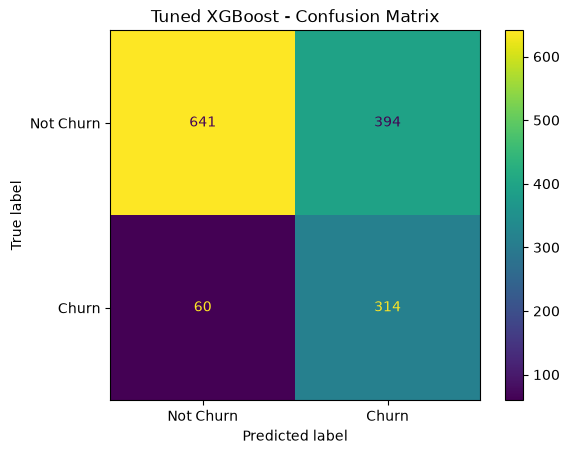

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get the best XGBoost model
best_xgb = grid_xgb.best_estimator_

# Predict on the unchanged test data
y_pred_xgb = best_xgb.predict(X_test)

# Classification Report
print("Classification Report - Tuned XGBoost:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

# Visualize Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["Not Churn", "Churn"]
)

plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

* The **XGBoost** model has a churn **recall of 84%**, which is **higher** than **Random Forest (77%)** and **Logistic Regression (71%)**. This means it can find more customers who are likely to leave. However, it still **misses** about **17%** of customers who actually leave. Its accuracy is 68%, which is lower than the other models, so accuracy is not the main measure for this problem.
* The model **correctly identified 314** customers who actually left. However, it **missed 60** customers who actually left and predicted them as customers who would stay. This is a relatively small number of missed customers and is fairly acceptable.

### Model Comparison

In [45]:
comparison = {
    "Model": [
        "Tuned Logistic Regression",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    "Precision": [0.54, 0.52, 0.44],
    "Recall": [0.71, 0.77, 0.84],
    "F1": [0.61, 0.62, 0.58]
}
comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Precision,Recall,F1
0,Tuned Logistic Regression,0.54,0.71,0.61
1,Tuned Random Forest,0.52,0.77,0.62
2,Tuned XGBoost,0.44,0.84,0.58


After comparing all three models, **XGBoost** has the **highest recall** for the churn class at **83%** . Although its precision is lower, predicting some customers as likely to leave when they will actually stay is less serious than missing customers who are likely to leave. Therefore, I would choose XGBoost as the best model because it identifies more customers who are likely to leave.

## MLflow Setup

In [ ]:
!pip install mlflow

In [2]:
import mlflow
print(mlflow.__version__)

3.15.2


In [3]:
mlflow.set_experiment("Customer Churn Model Comparison")
print("MLflow experiment is ready.")

2026/09/01 10:04:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/01 10:04:11 INFO mlflow.store.db.utils: Updating database tables
2026/09/01 10:04:21 INFO mlflow.tracking.fluent: Experiment with name 'Customer Churn Model Comparison' does not exist. Creating a new experiment.


MLflow experiment is ready.


## MLflow Model Tracking

In [4]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def log_model_to_mlflow(model_name, model, X_test, y_test):
    
    with mlflow.start_run(run_name=model_name):
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Log model parameters
        mlflow.log_params(model.get_params())
        
        # Log evaluation metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        
        # Log the trained model
        mlflow.sklearn.log_model(model, "model")
        
        print(f"{model_name}")
        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print("-" * 40)

In [46]:
log_model_to_mlflow(
    "Baseline Logistic Regression",
    model,
    X_test,
    y_test
)

2026/09/01 10:59:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Baseline Logistic Regression
Accuracy : 0.8062
Precision: 0.6603
Recall   : 0.5561
F1 Score : 0.6038
----------------------------------------


In [47]:
log_model_to_mlflow(
    "SMOTE Logistic Regression",
    smote_model,
    X_test,
    y_test
)

2026/09/01 11:00:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


SMOTE Logistic Regression
Accuracy : 0.7729
Precision: 0.5608
Recall   : 0.6658
F1 Score : 0.6088
----------------------------------------


In [48]:
log_model_to_mlflow(
    "Tuned Logistic Regression",
    best_lr,
    X_test,
    y_test
)

2026/09/01 11:04:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Tuned Logistic Regression
Accuracy : 0.7608
Precision: 0.5377
Recall   : 0.7059
F1 Score : 0.6104
----------------------------------------


In [49]:
log_model_to_mlflow(
    "Tuned Random Forest",
    best_rf,
    X_test,
    y_test
)

2026/09/01 11:09:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Tuned Random Forest
Accuracy : 0.7480
Precision: 0.5171
Recall   : 0.7701
F1 Score : 0.6187
----------------------------------------


In [51]:
import mlflow.xgboost

with mlflow.start_run(run_name="Tuned XGBoost"):
    
    y_pred = best_xgb.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    mlflow.log_params(best_xgb.get_params())
    
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    
    mlflow.xgboost.log_model(best_xgb, "model")
    
    print("Tuned XGBoost")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

2026/09/01 11:16:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Tuned XGBoost
Accuracy : 0.6778
Precision: 0.4435
Recall   : 0.8396
F1 Score : 0.5804


## Generate Churn Predictions Using Tuned XGBoost

In [57]:
# Generate churn probabilities using the selected XGBoost model
churn_probability = best_xgb.predict_proba(X_test)[:, 1]

# Generate predicted churn class
predicted_churn = best_xgb.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(churn_probability))

Predictions generated successfully.
Number of predictions: 1409


In [58]:
# Create prediction DataFrame
predictions_df = X_test.copy()

# Add actual churn, predicted churn, and churn probability
predictions_df["ActualChurn"] = y_test.values
predictions_df["PredictedChurn"] = predicted_churn
predictions_df["ChurnProbability"] = churn_probability

# Add a unique identifier based on the original row index
predictions_df["CustomerIndex"] = X_test.index

print("Prediction DataFrame created successfully.")
print("Shape:", predictions_df.shape)

predictions_df.head()

Prediction DataFrame created successfully.
Shape: (1409, 37)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_True,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalServiceUsed,AvgMonthlySpend,CustomerSegment,ActualChurn,PredictedChurn,ChurnProbability,CustomerIndex
437,1,0,1,1,72,1,1,114.050003,8468.20,1,...,1,0,0,6,117.613889,2,0,0,0.210539,437
2280,0,1,0,0,8,1,1,100.150002,908.55,1,...,1,0,0,3,113.568750,0,0,1,0.631553,2280
2235,0,0,1,1,41,1,1,78.349998,3211.20,1,...,1,0,0,4,78.321951,2,0,0,0.233452,2235
4460,1,0,1,0,18,1,0,78.199997,1468.75,0,...,0,1,0,2,81.597222,1,0,1,0.622899,4460
3761,0,0,1,0,72,1,1,82.650002,5919.35,1,...,1,0,0,5,82.213194,2,0,0,0.205953,3761


### Export Churn Predictions for Power BI

In [75]:
predictions_df.to_csv("churn_predictions.csv", index=False)

print("Churn predictions exported successfully.")

Churn predictions exported successfully.


In [81]:
predictions_df.to_csv(
    r"C:\Users\nandhini\Desktop\churn_predictions.csv",
    index=False
)

In [76]:
predictions_df["Contract"] = "Month-to-month"

predictions_df.loc[
    predictions_df["Contract_One year"] == 1,
    "Contract"
] = "One year"

predictions_df.loc[
    predictions_df["Contract_Two year"] == 1,
    "Contract"
] = "Two year"

In [77]:
predictions_df["Contract"].value_counts()

Contract
Month-to-month    773
Two year          336
One year          300
Name: count, dtype: int64

In [82]:
predictions_df.shape

(1409, 38)

In [83]:
pd.crosstab(
    predictions_df['Contract'],
    predictions_df['PredictedChurn']
)

PredictedChurn,0,1
Contract,,
Month-to-month,65,708
One year,300,0
Two year,336,0


## Global Feature Importance – Selected XGBoost Model

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# feature importance from the best XGBoost model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15 important features
top_features = feature_importance.head(15)
top_features


,Feature,Importance
26,Contract_Two year,0.226383
25,Contract_One year,0.183992
32,CustomerSegment,0.103986
3,Dependents,0.073395
13,OnlineSecurity_True,0.066073
19,TechSupport_True,0.064262
12,InternetService_No,0.063127
27,PaymentMethod_Credit card (automatic),0.059218
11,InternetService_Fiber optic,0.056399
15,OnlineBackup_True,0.034682


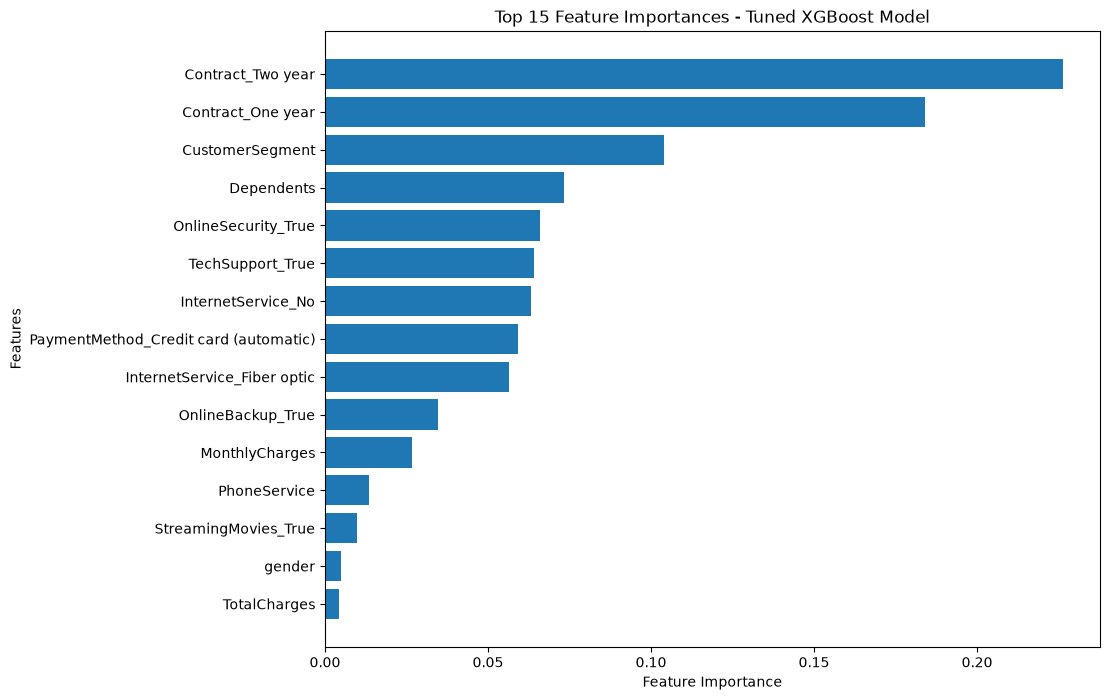

In [31]:
# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances - Tuned XGBoost Model')
plt.gca().invert_yaxis()
plt.show()

The XGBoost model found that **contract type** was the most important feature for predicting churn. Customer segment, which was created from tenure groups, was also one of the most important features. Online security and technical support were also useful for the model. Compared with Random Forest, Dependents was more important for XGBoost.

### LIME Explainability

In [ ]:
!pip install lime

In [34]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No Churn', 'Churn'],
    mode='classification',
    random_state=42
)

In [35]:
y_pred_xgb = best_xgb.predict(X_test)

# customer predicted to churn
churn_index = list(y_pred_xgb).index(1)
# customer  predicted to non churn
non_churn_index = list(y_pred_xgb).index(0)

print("Churn customer index:", churn_index)
print("Non-churn customer index:", non_churn_index)

Churn customer index: 1
Non-churn customer index: 0


In [38]:
# Explain the customer predicted to churn
lime_exp_churn = explainer.explain_instance(
    X_test.iloc[churn_index].values,
    best_xgb.predict_proba,
    num_features=10
)

# Display the explanation
lime_exp_churn.as_list()

[('Contract_Two year <= 0.00', 0.2846562663932079),
 ('Contract_One year <= 0.00', 0.21342632748852292),
 ('OnlineSecurity_True <= 0.00', 0.053861608465207635),
 ('InternetService_No <= 0.00', 0.04360995097955321),
 ('Dependents <= 0.00', 0.03875772417601897),
 ('MonthlyCharges > 90.00', 0.030824045686868275),
 ('0.00 < TechSupport_True <= 1.00', -0.020657170731465835),
 ('AvgMonthlySpend > 90.46', 0.017240188471968745),
 ('CustomerSegment <= 0.00', 0.0072771389967405155),
 ('PaymentMethod_Electronic check <= 0.00', -0.0047519703228932056)]

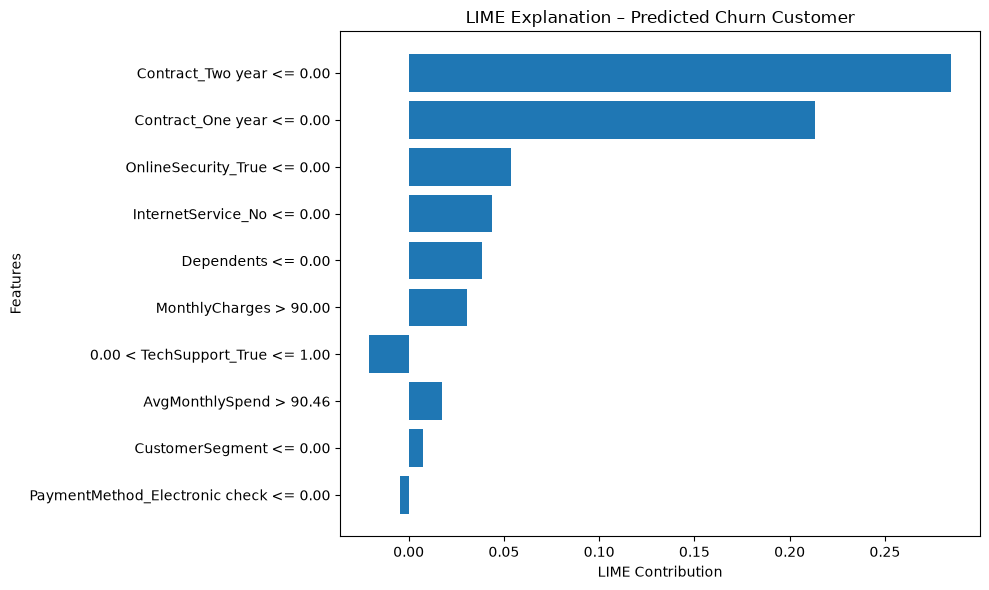

In [39]:
# Get LIME feature contributions
lime_values = lime_exp_churn.as_list()

#  bar chart
features = [item[0] for item in lime_values]
weights = [item[1] for item in lime_values]

plt.figure(figsize=(10, 6))
plt.barh(features, weights)

plt.xlabel("LIME Contribution")
plt.ylabel("Features")
plt.title("LIME Explanation – Predicted Churn Customer")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This customer was predicted to churn mainly because they did not have a one-year or two-year contract, did not have online security, and had high monthly charges. These factors contributed most strongly to the model's churn prediction.


In [41]:
# Explain the customer predicted NOT to churn
lime_exp_non_churn = explainer.explain_instance(
    X_test.iloc[non_churn_index].values,
    best_xgb.predict_proba,
    num_features=10
)
lime_exp_non_churn.as_list()


[('Contract_Two year > 0.00', -0.28646449341279595),
 ('Contract_One year <= 0.00', 0.20686876964910095),
 ('0.00 < OnlineSecurity_True <= 1.00', -0.05593778132327782),
 ('InternetService_No <= 0.00', 0.04081485405097294),
 ('0.00 < Dependents <= 1.00', -0.040092827964326345),
 ('MonthlyCharges > 90.00', 0.026018318548310108),
 ('0.00 < TechSupport_True <= 1.00', -0.024615000209176747),
 ('AvgMonthlySpend > 90.46', 0.011704770924959591),
 ('0.00 < InternetService_Fiber optic <= 1.00', 0.008862216626733345),
 ('StreamingMovies_No internet service <= 0.00', 0.0045961008077487495)]

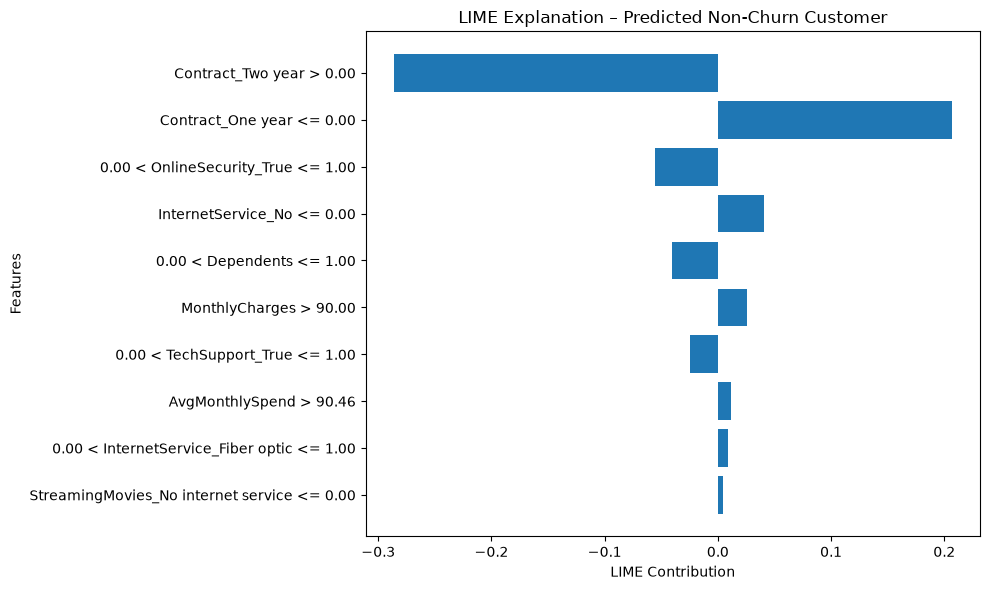

In [42]:
# Get the LIME feature contributions
lime_values_non_churn = lime_exp_non_churn.as_list()

# Create a bar chart
features = [item[0] for item in lime_values_non_churn]
weights = [item[1] for item in lime_values_non_churn]

plt.figure(figsize=(10, 6))
plt.barh(features, weights)

plt.xlabel("LIME Contribution")
plt.ylabel("Features")
plt.title("LIME Explanation – Predicted Non-Churn Customer")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This customer was predicted not to leave mainly because they have **a longer-term contract**. Other factors, such as having dependents, online security, and technical support, also helped the model predict the customer as non-churn. At the same time, their high monthly charges were a factor that increased the possibility of churn.

In [43]:
print("Number of features:", len(X_train.columns))
print("\nFeatures used by the model:")
print(X_train.columns.tolist())

Number of features: 33

Features used by the model:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_True', 'MultipleLines_No phone service', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_True', 'OnlineSecurity_No internet service', 'OnlineBackup_True', 'OnlineBackup_No internet service', 'DeviceProtection_True', 'DeviceProtection_No internet service', 'TechSupport_True', 'TechSupport_No internet service', 'StreamingTV_True', 'StreamingTV_No internet service', 'StreamingMovies_True', 'StreamingMovies_No internet service', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'TotalServiceUsed', 'AvgMonthlySpend', 'CustomerSegment']


## Data Validation & Pipeline Robustness

In [44]:
# Create a Valid New Customer
new_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 80.0,
    'TotalCharges': 960.0
}
print(new_customer)

{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 12, 'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 'MonthlyCharges': 80.0, 'TotalCharges': 960.0}


In [45]:
required_fields = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges'
]

print("Required fields:", len(required_fields))

Required fields: 19


In [49]:
 print("Validation passed.")

Validation passed.


In [50]:
# Prediction function with validation
def predict_new_customer(customer):

    try:
        # 1. Check for missing required fields
        missing_fields = [
            field for field in required_fields
            if field not in customer
        ]

        if missing_fields:
            raise ValueError(
                f"Missing required fields: {missing_fields}"
            )

        # 2. Check data types
        if not isinstance(customer['tenure'], (int, float)):
            raise TypeError("Tenure must be a number.")

        if not isinstance(customer['MonthlyCharges'], (int, float)):
            raise TypeError("MonthlyCharges must be a number.")

        if not isinstance(customer['TotalCharges'], (int, float)):
            raise TypeError("TotalCharges must be a number.")

        # 3. Check ranges
        if customer['tenure'] < 0 or customer['tenure'] > 72:
            raise ValueError("Tenure must be between 0 and 72 months.")

        if customer['MonthlyCharges'] < 0:
            raise ValueError("MonthlyCharges cannot be negative.")

        if customer['TotalCharges'] < 0:
            raise ValueError("TotalCharges cannot be negative.")

        if customer['SeniorCitizen'] not in [0, 1]:
            raise ValueError("SeniorCitizen must be 0 or 1.")

        # 4. Convert dictionary to DataFrame
        customer_df = pd.DataFrame([customer])

        # 5. Convert binary Yes/No columns
        bool_col = [
            'SeniorCitizen',
            'Partner',
            'Dependents',
            'PhoneService',
            'PaperlessBilling'
        ]

        for col in bool_col:
            if customer_df[col].iloc[0] in ['Yes', 'No']:
                customer_df[col] = customer_df[col].map({
                    'Yes': 1,
                    'No': 0
                })

        # 6. Encode gender
        customer_df['gender'] = customer_df['gender'].map({
            'Male': 1,
            'Female': 0
        })

        # 7. One-hot encode categorical columns
        customer_df = pd.get_dummies(
            customer_df,
            columns=categorical_cols,
            drop_first=True,
            dtype=int
        )

        # 8. Create TotalServiceUsed
        service_columns = [
            'OnlineSecurity_True',
            'OnlineBackup_True',
            'DeviceProtection_True',
            'TechSupport_True',
            'StreamingTV_True',
            'StreamingMovies_True'
        ]

        for col in service_columns:
            if col not in customer_df.columns:
                customer_df[col] = 0

        customer_df['TotalServiceUsed'] = (
            customer_df[service_columns].sum(axis=1)
        )

        # 9. Create AvgMonthlySpend
        customer_df['AvgMonthlySpend'] = 0.0

        mask = customer_df['tenure'] > 0

        customer_df.loc[mask, 'AvgMonthlySpend'] = (
            customer_df.loc[mask, 'TotalCharges'] /
            customer_df.loc[mask, 'tenure']
        )

        # 10. Create CustomerSegment
        def customer_segment(x):
            if x <= 12:
                return "New"
            elif x <= 36:
                return "Established"
            else:
                return "Loyal"

        customer_df['CustomerSegment'] = (
            customer_df['tenure'].apply(customer_segment)
        )

        # 11. Encode CustomerSegment the same way as training data
        customer_df = pd.get_dummies(
            customer_df,
            columns=['CustomerSegment'],
            drop_first=True,
            dtype=int
        )

        # 12. Match training features
        customer_df = customer_df.reindex(
            columns=X_train.columns,
            fill_value=0
        )

        # 13. Predict churn probability
        churn_probability = best_xgb.predict_proba(
            customer_df
        )[0][1]

        print("Validation passed.")
        print(f"Churn Probability: {churn_probability:.2%}")

        return churn_probability

    except (ValueError, TypeError) as e:
        raise ValueError(f"Invalid customer data: {e}")

    except Exception as e:
        raise RuntimeError(f"Prediction failed: {e}")

In [51]:
# Test with valid customer data
probability = predict_new_customer(new_customer)
print("Returned probability:", probability)

Validation passed.
Churn Probability: 66.36%
Returned probability: 0.66359216


In [52]:
# Test 1: Missing required field
bad_customer_1 = new_customer.copy()
del bad_customer_1['tenure']

try:
    predict_new_customer(bad_customer_1)
except Exception as e:
    print("Error:", e)

Error: Invalid customer data: Missing required fields: ['tenure']


In [53]:
# Test 2: Invalid negative tenure
bad_customer_2 = new_customer.copy()
bad_customer_2['tenure'] = -5

try:
    predict_new_customer(bad_customer_2)
except Exception as e:
    print("Error:", e)

Error: Invalid customer data: Tenure must be between 0 and 72 months.


## Package the Model as a Reusable Pipeline

In [54]:
import joblib
from sklearn.pipeline import Pipeline

In [55]:
model_pipeline = Pipeline([
    ('model', best_xgb)
])

print(model_pipeline)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy

In [56]:
# Save the pipeline as a .pkl
joblib.dump(model_pipeline, 'churn_prediction_pipeline.pkl')

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [57]:
# loading the .pkl file
loaded_pipeline = joblib.load('churn_prediction_pipeline.pkl')

In [58]:
sample_customer = X_test.iloc[[0]]

prediction = loaded_pipeline.predict_proba(sample_customer)[0][1]

print(f"Churn Probability: {prediction:.2%}")

Churn Probability: 21.05%
